In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

In [98]:
df = pd.read_pickle('../data/intermediate/tablon_analitico.pkl')

In [99]:
df.info()

<class 'pandas.DataFrame'>
Index: 136472 entries, 0 to 136475
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   fecha_hora               136472 non-null  datetime64[us]
 1   id_planta                136472 non-null  str           
 2   id_inversor              136472 non-null  str           
 3   potencia_dc_kw           136472 non-null  float64       
 4   potencia_ac_kw           136472 non-null  float64       
 5   energia_diaria_kwh       136472 non-null  float64       
 6   energia_total_kwh        136472 non-null  float64       
 7   fecha_x                  136472 non-null  object        
 8   id_sensor_meteorologico  136472 non-null  str           
 9   temperatura_ambiente_c   136472 non-null  float64       
 10  temperatura_modulo_c     136472 non-null  float64       
 11  irradiacion_wh_m2        136472 non-null  float64       
 12  fecha_y                  136472 

In [100]:
df = df.drop(columns=['fecha_x','fecha_y'])
df.set_index('fecha_hora', inplace=True)

In [101]:
#mover la coma de la potencia dc en planta 1, para que los valores sean correctos
mask = df['id_planta'] == 'p1'
df.loc[mask, 'potencia_dc_kw'] = df.loc[mask, 'potencia_dc_kw'] / 10

In [102]:
#comprovamos que los valores son correctos
df.groupby('id_planta')[['potencia_dc_kw']].mean()

,potencia_dc_kw
id_planta,
p1,314.717745
p2,246.701961


In [107]:
df = df.reset_index()

In [108]:
#crear variables de tiempo adicionales
# 1) extraer componentes
df['mes'] = df['fecha_hora'].dt.month
df['dia'] = df['fecha_hora'].dt.day
df['hora'] = df['fecha_hora'].dt.hour
df['minuto'] = df['fecha_hora'].dt.minute

# 2) 'time' como datetime (hora:minuto:segundo)
df['time'] = pd.to_datetime(df['fecha_hora'].dt.strftime('%H:%M:%S'), format='%H:%M:%S', errors='coerce')

# 3) comprobación
df[['fecha_hora','mes','dia','hora','minuto','time']].head()

,fecha_hora,mes,dia,hora,minuto,time
0,2020-05-15,5,15,0,0,1900-01-01
1,2020-05-15,5,15,0,0,1900-01-01
2,2020-05-15,5,15,0,0,1900-01-01
3,2020-05-15,5,15,0,0,1900-01-01
4,2020-05-15,5,15,0,0,1900-01-01


In [109]:
df['time'] = df['fecha_hora'].dt.time
df[['fecha_hora','mes','dia','hora','minuto','time']].head()

,fecha_hora,mes,dia,hora,minuto,time
0,2020-05-15,5,15,0,0,00:00:00
1,2020-05-15,5,15,0,0,00:00:00
2,2020-05-15,5,15,0,0,00:00:00
3,2020-05-15,5,15,0,0,00:00:00
4,2020-05-15,5,15,0,0,00:00:00


In [110]:
df['eficiencia'] = df['potencia_ac_kw'] / df['potencia_dc_kw'] * 100
df['eficiencia'] = df['eficiencia'].fillna(100)
df['eficiencia']= df['eficiencia'].clip(upper=100)
df['eficiencia'].describe()

count    136472.000000
mean         98.839717
std           1.198142
min          91.278968
25%          97.840674
50%          98.295398
75%         100.000000
max         100.000000
Name: eficiencia, dtype: float64

<Axes: >

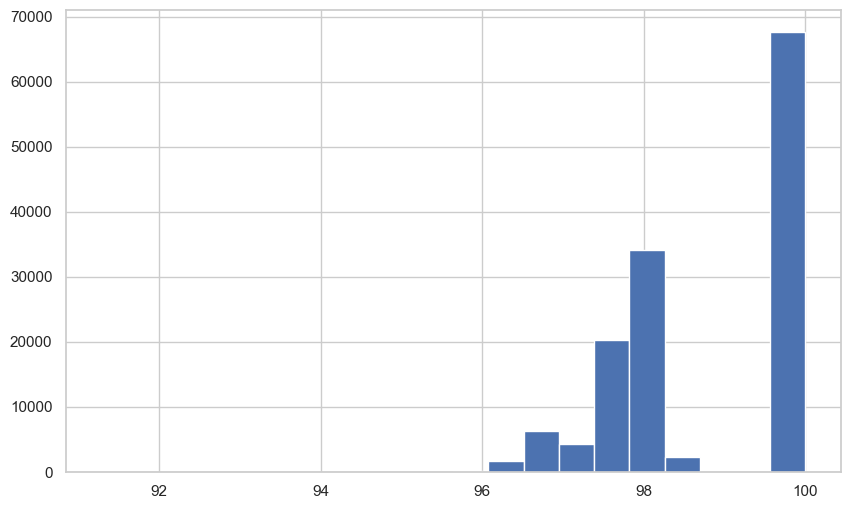

In [111]:
#comprovamos valores de eficiencia
df['eficiencia'].hist(bins=20)

In [112]:
df.set_index('fecha_hora', inplace=True)

In [113]:
orden=['id_planta','id_inversor','id_sensor_meteorologico','mes',
       'dia','time','hora','minuto','irradiacion_wh_m2','temperatura_ambiente_c',
       'temperatura_modulo_c','potencia_dc_kw','eficiencia','potencia_ac_kw',
       'energia_diaria_kwh', 'energia_total_kwh']
df = df[orden]

In [114]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 136472 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_planta                136472 non-null  str    
 1   id_inversor              136472 non-null  str    
 2   id_sensor_meteorologico  136472 non-null  str    
 3   mes                      136472 non-null  int32  
 4   dia                      136472 non-null  int32  
 5   time                     136472 non-null  object 
 6   hora                     136472 non-null  int32  
 7   minuto                   136472 non-null  int32  
 8   irradiacion_wh_m2        136472 non-null  float64
 9   temperatura_ambiente_c   136472 non-null  float64
 10  temperatura_modulo_c     136472 non-null  float64
 11  potencia_dc_kw           136472 non-null  float64
 12  eficiencia               136472 non-null  float64
 13  potencia_ac_kw           136472 non-

In [115]:
df.head(1)

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15,p1,1BY6WEcLGh8j5v7,HmiyD2TTLFNqkNe,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6259559.0


In [116]:
#df a nivel diario para poder visualizar los datos de forma agrupada por dia y encontrar patrones distintos a lo largo del tiempo
df_diario = df.groupby(['id_planta', 'id_inversor']).resample('D').agg({
    'irradiacion_wh_m2' : ['min', 'mean', 'max', 'sum'],
    'temperatura_ambiente_c' : ['min', 'mean', 'max'],
    'temperatura_modulo_c' : ['min', 'mean', 'max'],
    'potencia_dc_kw' : ['min', 'mean', 'max'],
    'eficiencia' : ['min', 'mean', 'max'],
    'potencia_ac_kw' : ['min', 'mean', 'max'],
    'energia_diaria_kwh' : ['min', 'mean', 'max', 'sum'],
    'energia_total_kwh' : ['min', 'mean', 'max']
})

In [52]:
df_diario.columns = ['_'.join(col).strip() for col in df_diario.columns.values]
df_diario.head()

irradiacion_wh_m2_min  \
id_planta id_inversor     fecha_hora                          
p1        1BY6WEcLGh8j5v7 2020-05-15                    0.0   
                          2020-05-16                    0.0   
                          2020-05-17                    0.0   
                          2020-05-18                    0.0   
                          2020-05-19                    0.0   

                                      irradiacion_wh_m2_mean  \
id_planta id_inversor     fecha_hora                           
p1        1BY6WEcLGh8j5v7 2020-05-15                0.204699   
                          2020-05-16                0.211951   
                          2020-05-17                0.238869   
                          2020-05-18                0.159026   
                          2020-05-19                0.194031   

                                      irradiacion_wh_m2_max  \
id_planta id_inversor     fecha_hora                          
p1        1BY6WEcLGh8j5v7 2020-05-15               0.893661   
                          2020-05-16               0.812241   
                          2020-05-17               0.997904   
                          2020-05-18               0.971481   
                          2020-05-19               0.835832   

                                      irradiacion_wh_m2_sum  \
id_planta id_inversor     fecha_hora                          
p1        1BY6WEcLGh8j5v7 2020-05-15              19.037010   
                          2020-05-16              18.651690   
                          2020-05-17              22.931378   
                          2020-05-18              15.266485   
                          2020-05-19              18.044861   

                                      temperatura_ambiente_c_min  \
id_planta id_inversor     fecha_hora                               
p1        1BY6WEcLGh8j5v7 2020-05-15                   22.037482   
                          2020-05-16                   21.496287   
                          2020-05-17                   21.209418   
                          2020-05-18                   20.961525   
                          2020-05-19                   22.388784   

                                      temperatura_ambiente_c_mean  \
id_planta id_inversor     fecha_hora                                
p1        1BY6WEcLGh8j5v7 2020-05-15                    27.430823   
                          2020-05-16                    26.780538   
                          2020-05-17                    26.686727   
                          2020-05-18                    23.850938   
                          2020-05-19                    25.338021   

                                      temperatura_ambiente_c_max  \
id_planta id_inversor     fecha_hora                               
p1        1BY6WEcLGh8j5v7 2020-05-15                   34.430943   
                          2020-05-16                   32.524149   
                          2020-05-17                   35.252486   
                          2020-05-18                   28.367100   
                          2020-05-19                   30.368632   

                                      temperatura_modulo_c_min  \
id_planta id_inversor     fecha_hora                             
p1        1BY6WEcLGh8j5v7 2020-05-15                 20.290726   
                          2020-05-16                 19.592692   
                          2020-05-17                 20.377121   
                          2020-05-18                 19.477531   
                          2020-05-19                 20.062144   

                                      temperatura_modulo_c_mean  \
id_planta id_inversor     fecha_hora                              
p1        1BY6WEcLGh8j5v7 2020-05-15                  32.582964   
                          2020-05-16                  31.858851   
                          2020-05-17                  32.740435   
                          2

In [53]:
df_diario = df_diario.reset_index()
df_diario = df_diario.set_index('fecha_hora')
df_diario.head()

,id_planta,id_inversor,irradiacion_wh_m2_min,irradiacion_wh_m2_mean,irradiacion_wh_m2_max,irradiacion_wh_m2_sum,temperatura_ambiente_c_min,temperatura_ambiente_c_mean,temperatura_ambiente_c_max,temperatura_modulo_c_min,temperatura_modulo_c_mean,temperatura_modulo_c_max,potencia_dc_kw_min,potencia_dc_kw_mean,potencia_dc_kw_max,eficiencia_min,eficiencia_mean,eficiencia_max,potencia_ac_kw_min,potencia_ac_kw_mean,potencia_ac_kw_max,energia_diaria_kwh_min,energia_diaria_kwh_mean,energia_diaria_kwh_max,energia_diaria_kwh_sum,energia_total_kwh_min,energia_total_kwh_mean,energia_total_kwh_max
fecha_hora,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.204699,0.893661,19.037010,22.037482,27.430823,34.430943,20.290726,32.582964,55.030613,0.0,253.054512,1064.275000,96.350365,98.816849,100.0,0.0,247.812372,1039.350000,0.0,2641.120776,5754.0,245624.232144,6259559.0,6.262200e+06,6265313.0
2020-05-16,p1,1BY6WEcLGh8j5v7,0.0,0.211951,0.812241,18.651690,21.496287,26.780538,32.524149,19.592692,31.858851,54.232746,0.0,291.624858,1120.900000,96.521739,98.732919,100.0,0.0,285.505580,1095.285714,0.0,3380.406047,6292.0,297475.732142,6265313.0,6.268693e+06,6271605.0
2020-05-17,p1,1BY6WEcLGh8j5v7,0.0,0.238869,0.997904,22.931378,21.209418,26.686727,35.252486,20.377121,32.740435,63.145582,0.0,300.041481,1141.642857,96.416185,98.837466,100.0,0.0,293.467187,1114.814286,0.0,3473.035714,7045.0,333411.428572,6271605.0,6.275078e+06,6278650.0
2020-05-18,p1,1BY6WEcLGh8j5v7,0.0,0.159026,0.971481,15.266485,20.961525,23.850938,28.367100,19.477531,27.814344,53.936739,0.0,212.531566,1223.885714,96.605431,98.856972,100.0,0.0,208.026116,1193.628571,0.0,2271.423549,4998.0,218056.660714,6278650.0,6.280921e+06,6283648.0
2020-05-19,p1,1BY6WEcLGh8j5v7,0.0,0.194031,0.835832,18.044861,22.388784,25.338021,30.368632,20.062144,29.725163,51.847742,0.0,249.760503,1085.450000,96.556671,98.977423,100.0,0.0,244.528783,1059.800000,0.0,3087.064900,6449.0,287097.035714,6283648.0,6.286728e+06,6290097.0


In [118]:
df.to_pickle('../data/intermediate/tablon_analitico_preparado.pkl')
df_diario.to_pickle('../data/intermediate/tablon_analitico_diario.pkl')